# Error Analysis: K-Means

- **Question:** Can we clearly separate predictions vs non-predictions based on embeddings alone?

In [1]:
import os
import sys

import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataVisualizing

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

## Load Data

In [3]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
# combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/combined_generated_fin_phrase_bank')
train_data = os.path.join(base_data_path, 'classification_results/train_synthetic-v1_2026-03-23/seed3')

In [4]:
# model_results_path = os.path.join(combine_data_path, 'inference_chronicle2050_2026-03-07_21-51-47.csv')
test_data = os.path.join(train_data, 'external_fpb-maya-binary-imbalanced-96d-v1/', 'ml_classifiers_fpb-maya-binary-imbalanced-96d-v1.csv')

model_results_df = DataProcessing.load_from_file(test_data, 'csv', sep=',')
cols_to_drop = ["Dataset Name", "Author Type", "maya_label"]
compare_y_vs_yhats_df = DataProcessing.drop_df_columns(model_results_df, cols_to_drop)
compare_y_vs_yhats_df.head(3)

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,1,1,1,0,1,1,1,1
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,1,0,0,1,1,1,0,1
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,1,1,1,1,1,1,1,1


In [5]:
if "Sentence Label" in compare_y_vs_yhats_df.columns:
    print(True)

True


## Plot Clusters

### Region to Filer: None

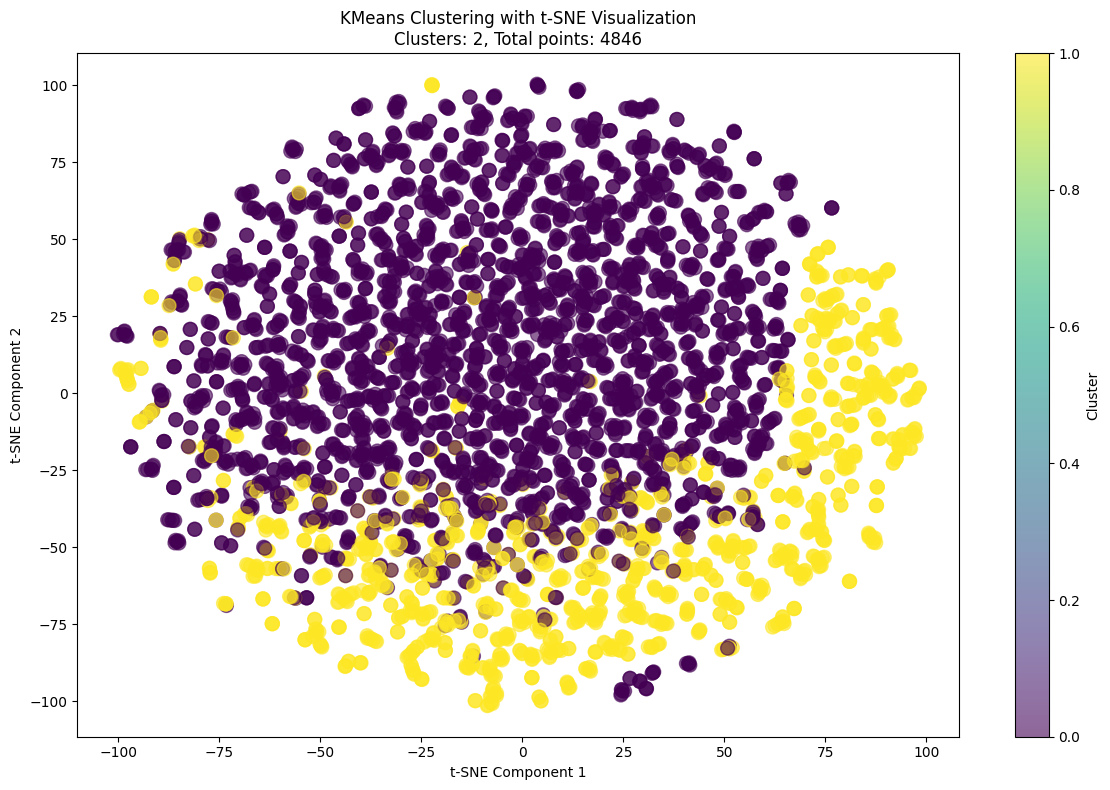

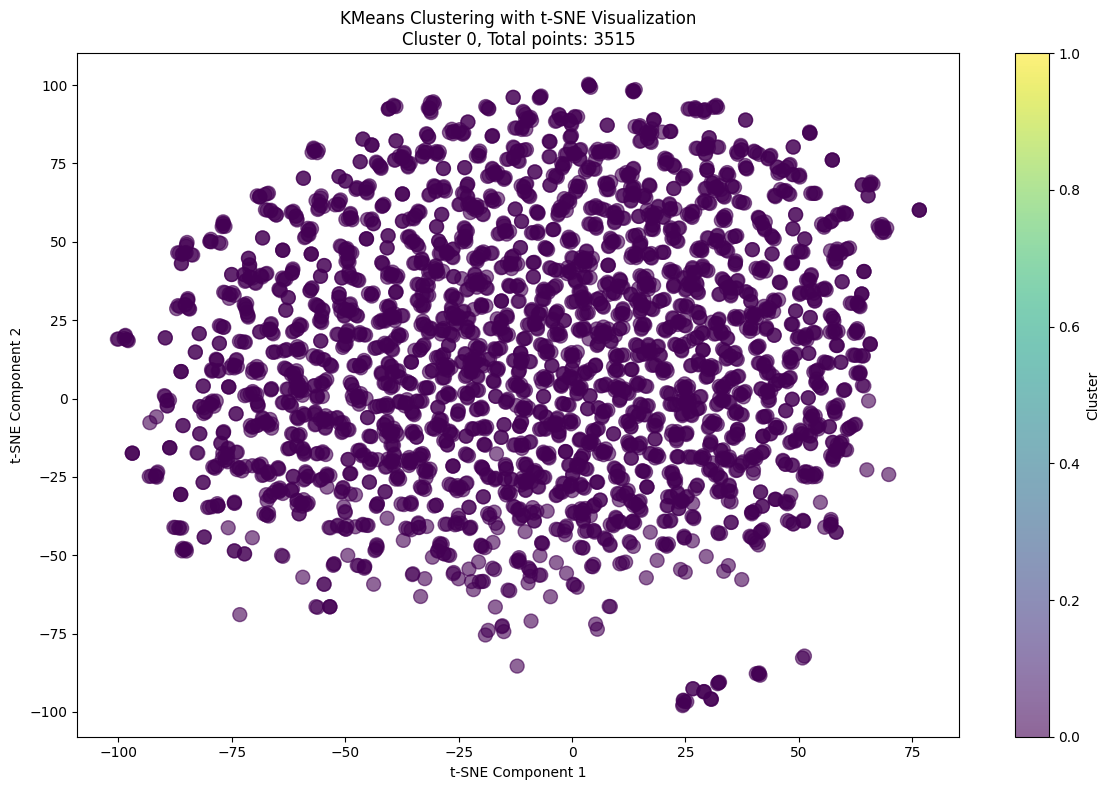

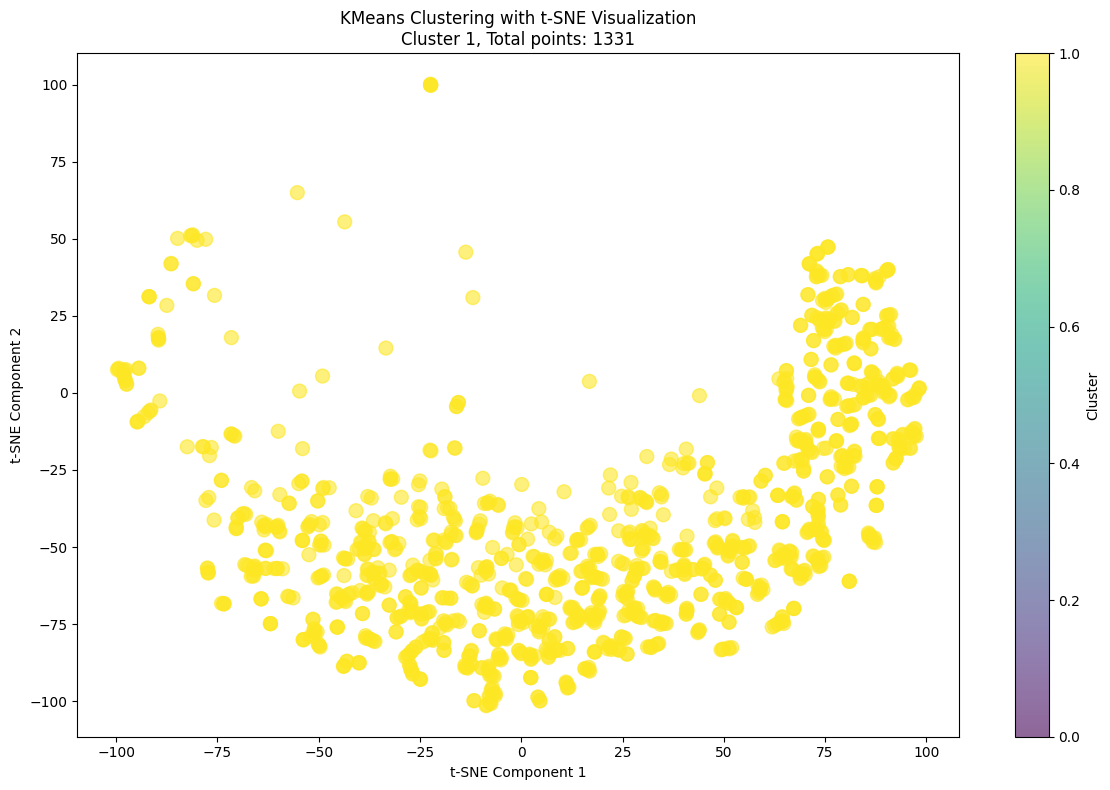


--- Sample Sentences Per Cluster ---

Cluster 0 (3515 sentences):
  Label 0 (Non-Prediction): 3137 sentences (89.2%)
  Label 1 (Prediction): 378 sentences (10.8%)

  Sample Sentences:
  - [0] Technopolis has set aside a plot of land measuring 4.6 hectares to build the park , Mikkonen said .
  - [1] Following the issue , the number of shares in the Swedish company will grow by 9 % .
  - [0] The EB Tough VoIP Field Phone is equipped with an integrated speaker , Ethernet and SHDSL connectivity , and enables several innovative applications .
  - [0] The divestment is in line with the company 's plans to focus on selected growth segments and streamline corporate structure , the company explained .
  - [0] According to the CEO of Nordea Bank Estonia Vahur Kraft , Nordea Finland and Stockmann have been cooperating for more than ten years .
  - [0] The opening of the portal is part of the expansion strategy of Alma Media 's Marketplaces business unit .
  - [0] In the meantime the CEO 's dutie

(                                                                                                                                                                                                                           Base Sentence  \
 0                         With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .   
 1                            According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .   
 2                                                     TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .   
 3                                                  

In [6]:
DataVisualizing.plot_kmeans_tsne(
    df=compare_y_vs_yhats_df,
    text_column='Base Sentence',
    embedding_col_name="Base Sentence Embedding",
    n_clusters=2,
    show_sentences_per_cluster=7,
    sentence_label='Sentence Label'
    )

### Takeaways

1. Since imbalanced data set (90.5% non-predictions and 9.5% predictions), the skewness of non-predictions to predictions for each cluster is valid.
2. Visually, the embeddings, are somewhat linearly separable because majority of the purple are above and majority of the yellow are below, which suggests embeddings capture some underlying semantic structure, but further sentence-level analysis is needed to determine whether that structure corresponds to the prediction/non-prediction distinction.
3. Embeddings alone are not enough, so need futher analyses at sentence-level.


### Region to Filter: Middle

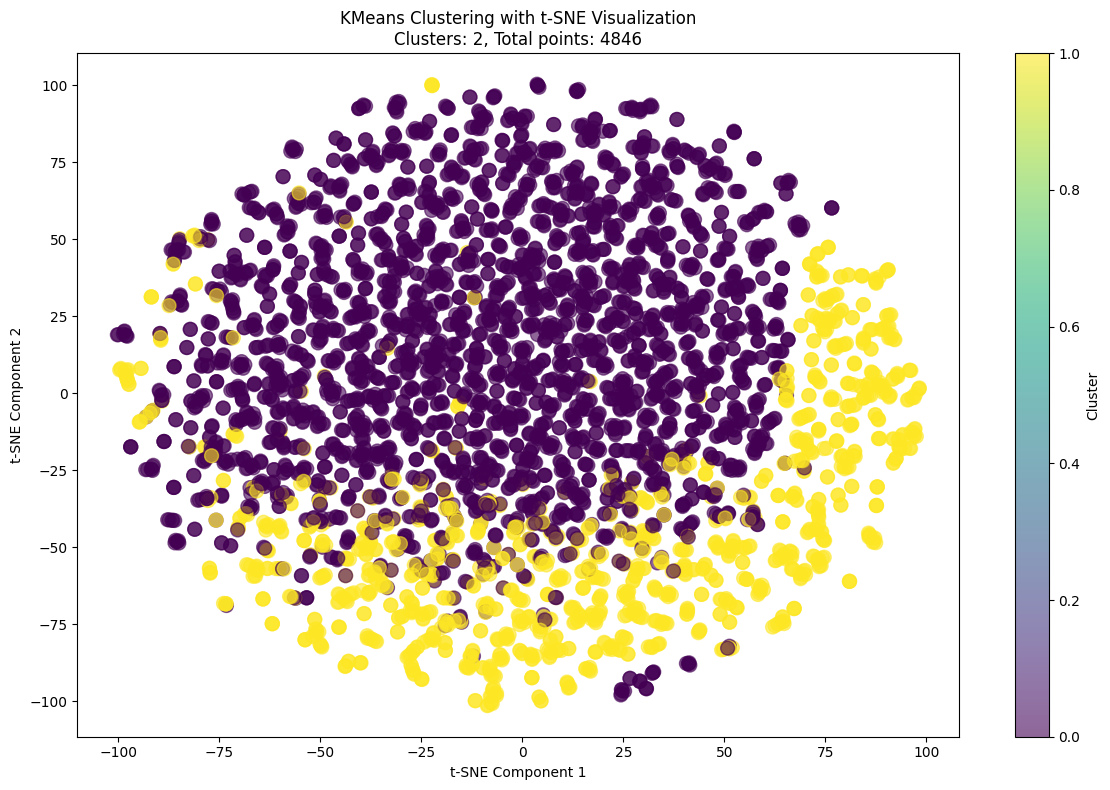

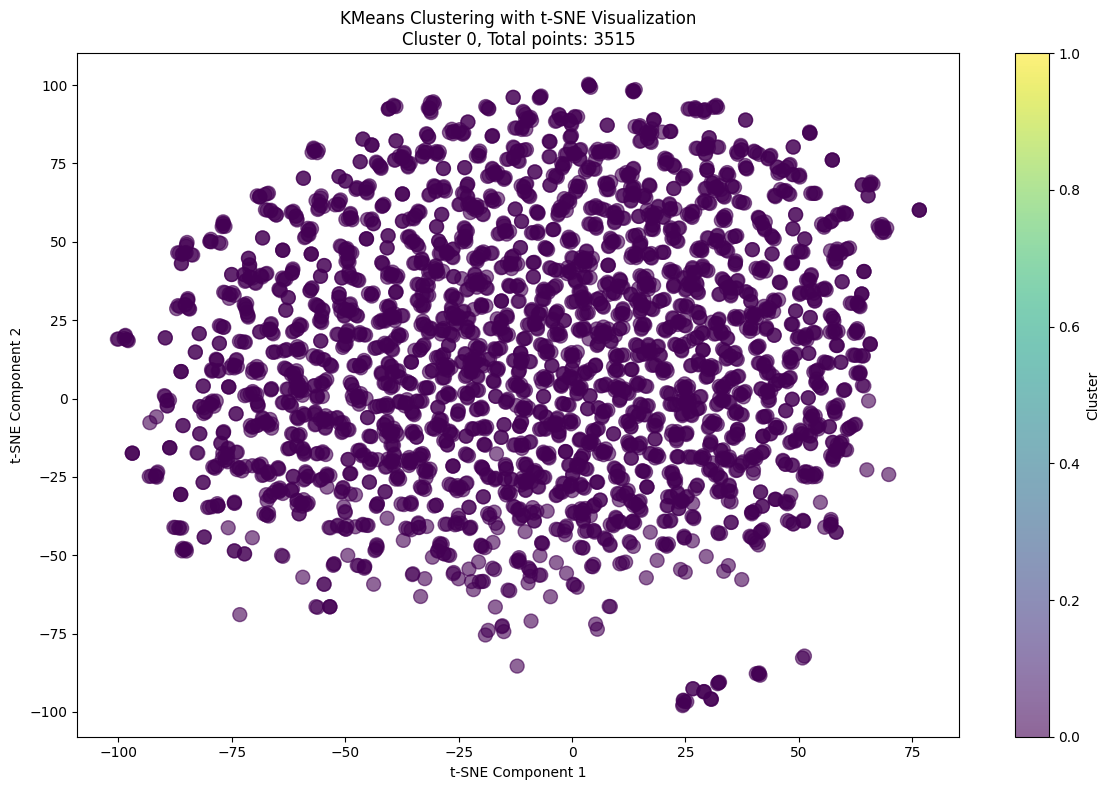

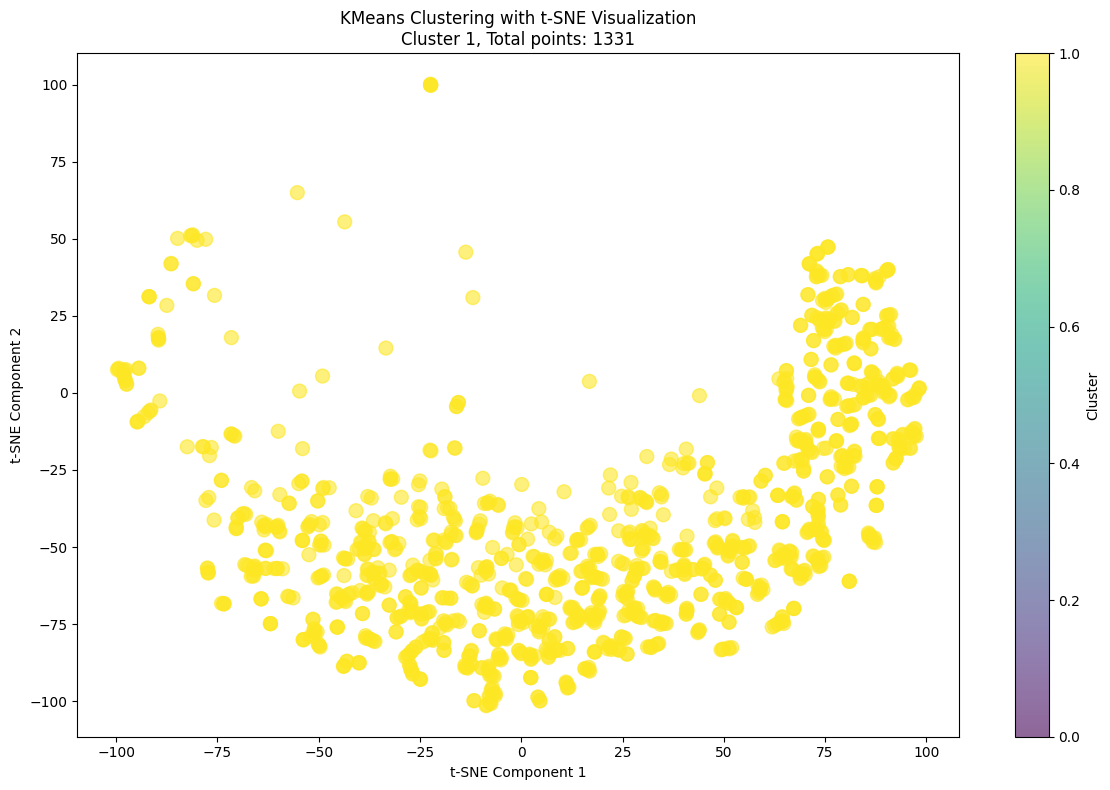


--- Sample Sentences Per Cluster ---

Cluster 0 (3515 sentences):
  Label 0 (Non-Prediction): 3137 sentences (89.2%)
  Label 1 (Prediction): 378 sentences (10.8%)

  Sample Sentences:
  - [0] Productional situation has now improved .
  - [0] We can capitalize on our experience from a number of similar bridge projects in the Nordic countries .
  - [0] Stockholm , 3 March 2011 About Cybercom The Cybercom Group is a high-tech consultancy that offers global sourcing for end-to-end solutions .
  - [0] In Finland , Martela offers a comprehensive service that can cover the entire process of change from initial inventory and design to removal and maintenance .
  - [0] Major Order in India Comptel Corporation has received a significant long-term order for mediation and provisioning solutions being used by a leading operator in India .
  - [0] The fixed-term contract of Mr. Jarmo Ukonaho , the current General Manager of Incap 's Indian operations , will finish by the end of the year .
  - [0] T

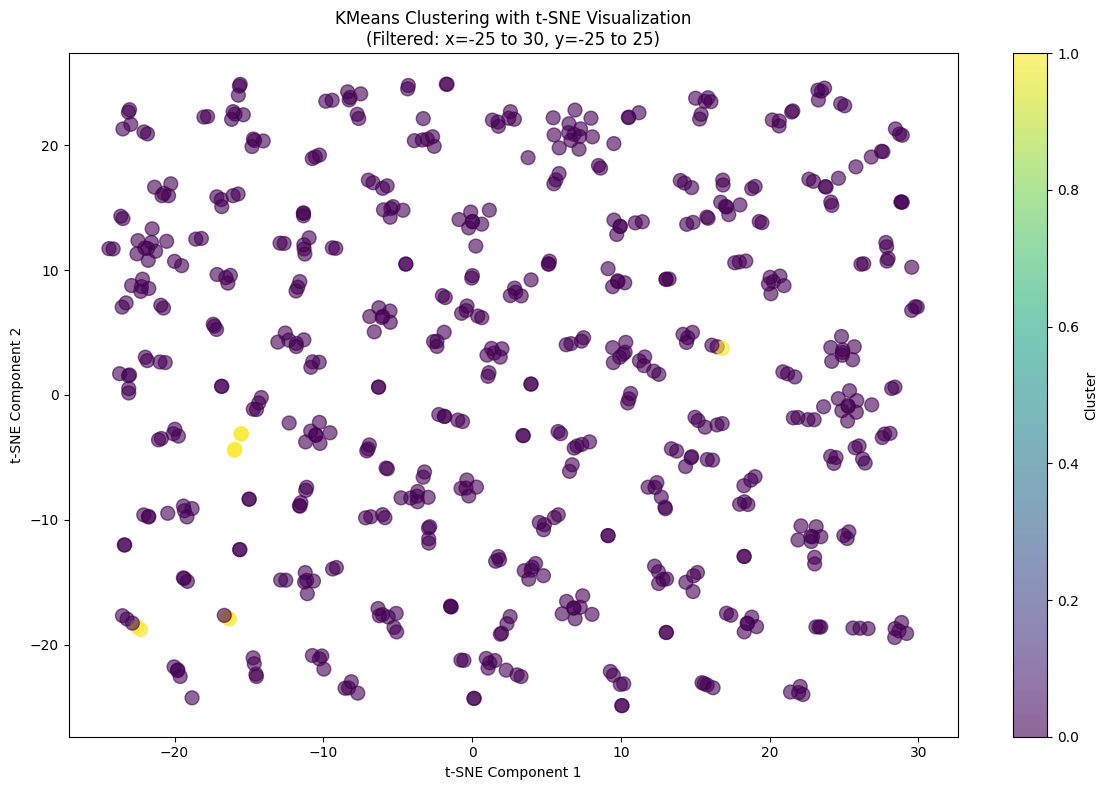


Filtered points: 599 out of 4846


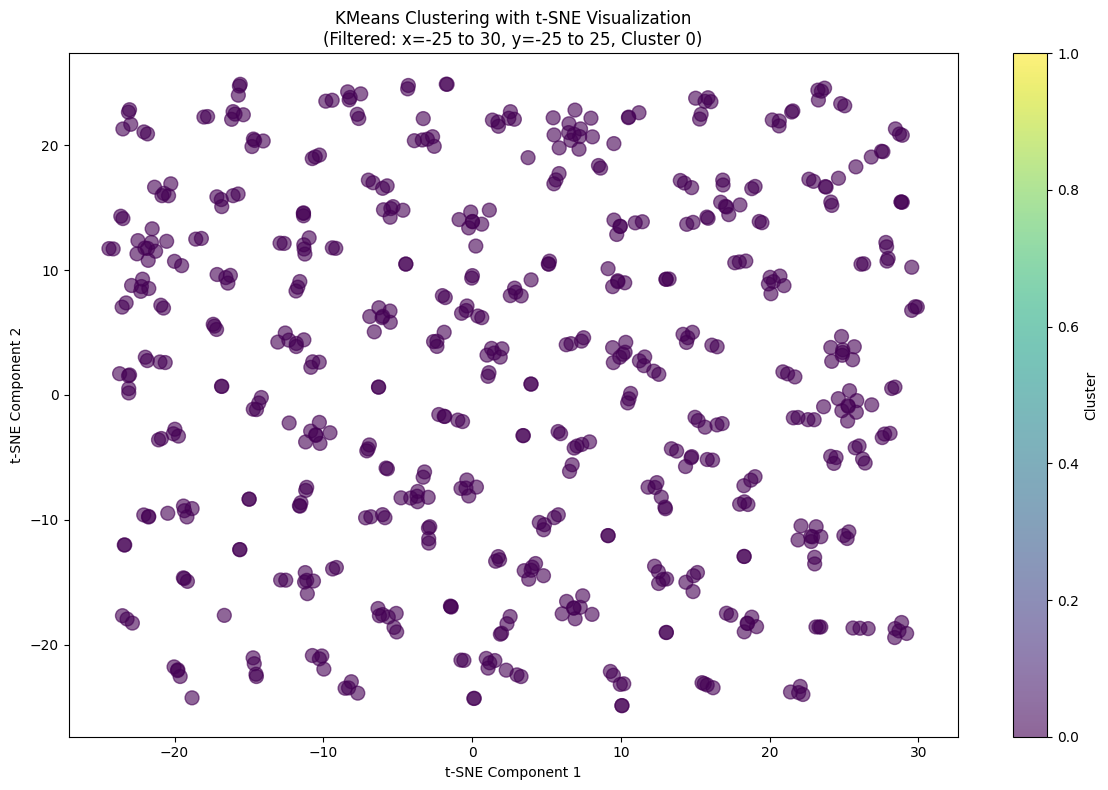

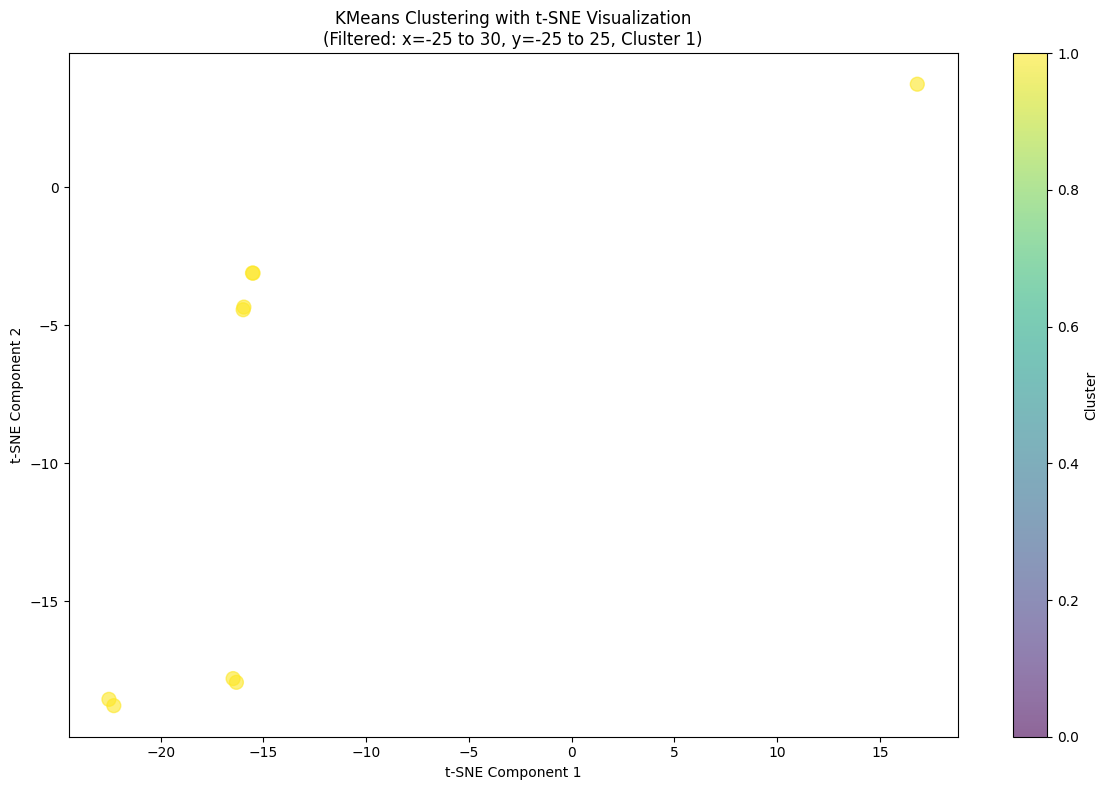


--- Sample Sentences Per Cluster ---

Cluster 0 (590 sentences):
  Label 0 (Non-Prediction): 511 sentences (86.6%)
  Label 1 (Prediction): 79 sentences (13.4%)

  Sample Sentences:
  - [0] Initially , the company said a maximum of 15 people would be made redundant in the parent company and about 15 in its subsidiaries .
  - [0] Also construction expenses have gone up in Russia .
  - [0] In 2007 , almost two thirds of Orion 's net sales came from these drugs .
  - [0] Autotank Group is part of Aspo 's Systems Division .
  - [0] The company aims to maintain this trend in profitability during the current year .
  - [0] It is profitable to make pulp , paper , and sawn goods in areas where the combination of these factors is good .
  - [0] The hull of the vessel was built one block at a time and Ruukki delivered the plate material for each block as construction progressed .

Cluster 1 (9 sentences):
  Label 0 (Non-Prediction): 9 sentences (100.0%)

  Sample Sentences:
  - [0] Beef imports 

In [7]:
filtered_df, cluster_dfs = DataVisualizing.plot_kmeans_tsne(
    df=compare_y_vs_yhats_df,
    text_column='Base Sentence',
    embedding_col_name="Base Sentence Embedding",
    n_clusters=2,
    show_sentences_per_cluster=7,
    sentence_label='Sentence Label',
    filter_x_axis=[-25, 30],
    filter_y_axis=[-25, 25]
    )

In [24]:
cluster_dfs[0].sort_values('tsne_x', ascending=False)[120:140]

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Cluster,tsne_x,tsne_y
284,"According to the company , a decision in the issue will be made in the summer of 2010 , at the earliest , and in the summer of 2011 , at the latest .",0,[ 3.84310633e-02 2.10437879e-01 -6.06185151e-03 -1.82373486e-02\n 2.74518412e-02 5.07348590e-02 3.91954407e-02 -3.34346630e-02\n -2.83824690e-02 2.38081789e+00 -2.98552871e-01 -1.92732606e-02\n 2.04977006e-01 -7.81511068e-02 -7.62658715e-02 -1.29384235e-01\n -8.83420557e-02 1.17940497e+00 -1.33355781e-01 -4.58536185e-02\n -1.43800152e-03 -8.38788450e-02 -6.51351437e-02 -1.82261225e-02\n 1.94722619e-02 8.96198079e-02 -1.09017052e-01 -2.50934809e-02\n -7.49402540e-03 3.38995904e-02 1.47157097e-02 9.73337889e-03\n -9.40005481e-02 2.44149715e-01 9.95849967e-02 -3.10000256e-02\n 1.48593187e-02 5.83243631e-02 7.27253035e-03 -2.89745554e-02\n -5.25782630e-02 1.65319502e-01 -4.84741526e-03 -1.02788702e-01\n 5.67380153e-02 7.97711387e-02 -9.60988775e-02 -5.20154163e-02\n 5....,1,1,1,1,1,0,0,1,1,0,18.309420,-8.557676
555,Last year 's third quarter result had been burdened by costs stemming from restructuring in the US .,0,[-1.01176113e-01 2.13753119e-01 4.03001122e-02 1.41963428e-02\n -1.24030588e-02 -1.48295641e-01 1.61424354e-02 1.60922222e-02\n -1.60874669e-02 2.46501660e+00 -1.93956882e-01 8.09141099e-02\n 1.41852841e-01 -5.05874306e-02 -7.99096078e-02 -8.05651098e-02\n 7.23119453e-02 8.47419381e-01 -7.84529895e-02 6.56038076e-02\n -5.62711544e-02 -5.61968349e-02 2.40583392e-03 9.89095569e-02\n 5.79256080e-02 5.68992496e-02 -1.12670846e-01 6.17520623e-02\n -3.33296135e-02 2.64078658e-02 -8.40061009e-02 -3.54824476e-02\n -6.24962784e-02 -1.26815056e-02 2.60545406e-02 1.16789460e-01\n 1.70962587e-02 4.21220772e-02 5.26487827e-02 -9.77544412e-02\n 4.96950001e-02 8.51192176e-02 8.19113851e-02 4.80748005e-02\n -4.13735025e-02 2.27086078e-02 -5.02780490e-02 -1.44945749e-03\n 3....,0,0,0,0,1,0,0,0,0,0,18.294275,-18.970367
496,"In February 2011 , new wording of Identity Documents Act that makes Mobile ID a state-approved electronic document as of February 1st 2011 entered into force .",0,[ 1.03218257e-02 1.30578414e-01 1.46006513e-02 7.03135831e-03\n 8.21478590e-02 4.67071682e-02 7.38231242e-02 -1.89041048e-01\n 7.65701942e-03 1.91329098e+00 -2.94152886e-01 1.22556828e-01\n 8.39970633e-02 -7.52083510e-02 -1.60212964e-01 8.04813765e-03\n -1.05281428e-01 1.33899152e+00 -4.54687737e-02 -2.42307298e-02\n 7.80387521e-02 -5.08500710e-02 3.49882804e-02 -7.78920949e-02\n 6.74212575e-02 9.89441425e-02 -8.23230818e-02 -1.00788601e-01\n -3.14390734e-02 6.38823584e-02 -3.15459259e-02 7.40830228e-03\n -4.03682403e-02 1.55399650e-01 3.95841198e-03 -9.93639454e-02\n 5.80118112e-02 6.35005832e-02 -2.77203359e-02 -1.01362787e-01\n 7.77966753e-02 9.20233428e-02 1.38906032e-01 -9.69753116e-02\n -1.44707961e-02 -5.41125797e-02 -3.37165855e-02 2.43545882e-02\n 3....,1,1,1,1,0,1,0,1,0,0,18.287004,-12.933634
441,"In addition to verification of an identity and digital signatures , new state-approved Mobile ID enables to cast votes in elections as well .",0,[-1.16129620e-02 9.96809900e-02 2.13916935e-02 -5.13829961e-02\n 8.79132301e-02 7.04443082e-02 -4.49010916e-02 -8.44416916e-02\n 5.05740230e-04 2.02820563e+00 -1.57209784e-01 3.29809636e-02\n 6.43608067e-03 -1.10015705e-01 -1.46037951e-01 4.23126807e-03\n -5.51577769e-02 1.39550340e+00 -1.17476307e-01 -2.42309589e-02\n -8.72668717e-03 2.26572845e-02 -8.29450339e-02 -1.15410432e-01\n 5.18407263e-02 4.63432260e-02 -1.23217434e-01 -2.93728504e-02\n 5.65406121e-03 8.83732736e-03 1.25377238e-01 2.68434305e-02\n 3.30089964e-02 8.59685708e-03 5.49204946e-02 -1.35637537e-01\n 3.79947620e-03 5.18984459e-02 3.35453227e-02 -1.16866082e-01\n -3.21106762e-02 6.96787760e-02 5.21958992e-02 -1.2

In [13]:
cluster_dfs[1]

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier,Cluster,tsne_x,tsne_y
91,Aviation Systems Maintenance is based in Kansas and generated net sales of USD 2.6 million for 2008 .,0,[-1.65779620e-01 2.73763746e-01 7.26473182e-02 -1.73913941e-01\n 6.45283461e-02 2.17755465e-03 3.29749398e-02 1.33852614e-02\n 1.07930623e-01 1.70051515e+00 -2.74877757e-01 6.10220022e-02\n -3.46475840e-03 -3.75106558e-02 -1.64850429e-02 -4.68372889e-02\n 2.00322196e-02 1.54656827e+00 -1.80504933e-01 2.21865010e-02\n 6.33251071e-02 2.94347797e-02 -8.65225643e-02 -4.37444672e-02\n 1.34975851e-01 8.07806551e-02 -1.93331227e-01 -2.25729048e-02\n 7.26369843e-02 8.69102180e-02 -1.25509992e-04 -1.58999041e-01\n 1.24184974e-02 5.74625060e-02 -4.04746085e-02 1.10071618e-02\n -1.52071819e-01 -3.23933363e-02 -3.40160318e-02 6.44486099e-02\n 6.62334114e-02 1.08324289e-01 2.36452609e-01 4.06966880e-02\n -2.74084359e-02 -2.41301693e-02 -1.31381704e-02 -3.69691178e-02\n 2....,0,0,0,0,0,0,0,0,0,1,-16.313662,-17.945274
173,"According to preliminary data from Slovakia 's Statistics Office , goods worth E36 .4 million were imported from Finland between January and October 2010 , making up 0.1 percent of Slovakia 's total imports .",0,[-9.66691002e-02 1.70184135e-01 1.09543139e-02 7.73075297e-02\n 4.19805162e-02 -1.74125824e-02 6.33978918e-02 -6.35565966e-02\n -1.90611947e-02 1.65664983e+00 -3.48551780e-01 9.63108316e-02\n 6.22210242e-02 -3.39921042e-02 -5.26284203e-02 -1.27292097e-01\n -4.82884608e-02 1.10996115e+00 -5.18795699e-02 2.24611647e-02\n 6.93747476e-02 6.42322898e-02 4.75785136e-02 -8.88202488e-02\n 1.53883947e-02 -5.26708029e-02 -6.90600276e-02 -7.08594993e-02\n 1.15099503e-02 -1.84008237e-02 6.01359904e-02 -5.40653244e-02\n 4.67902981e-02 1.05800971e-01 -4.97456528e-02 2.17634183e-03\n -7.77739286e-02 -2.67829150e-02 6.59855977e-02 2.99507678e-02\n -1.01609103e-01 9.10147130e-02 1.43585593e-01 7.03518838e-02\n -7.69549683e-02 -3.63393612e-02 1.01824291e-02 -8.77025649e-02\n -1....,0,0,0,0,0,0,0,0,0,1,-15.949053,-4.344628
266,TeliaSonera has secured deliveries for 4G modems with support for 3G and 2G during the second quarter 2010 .,0,[-4.60897684e-02 2.76046008e-01 -7.36643597e-02 2.16990840e-02\n 7.55421445e-02 -1.00061171e-01 4.09687795e-02 -4.45049405e-02\n 2.32556626e-01 1.39640856e+00 -1.84851542e-01 6.30359054e-02\n 5.65630533e-02 2.54969462e-03 -2.14375928e-02 -1.59289330e-01\n 3.10617015e-02 1.39527845e+00 -3.12774390e-01 8.91527068e-03\n -5.30496091e-02 -5.75690009e-02 -1.07641242e-01 2.04808116e-02\n 1.02714829e-01 -1.23817705e-01 -2.24410355e-01 -5.78760989e-02\n 2.22414942e-03 3.27775851e-02 -8.99448097e-02 -4.58841883e-02\n 2.21182145e-02 1.53797716e-02 5.81568591e-02 -1.25439495e-01\n -3.04997638e-02 -2.12720851e-03 -6.96023032e-02 -6.94170455e-03\n -1.42631670e-02 3.93242687e-02 2.13927254e-02 -1.12288930e-02\n -6.53780028e-02 9.08448920e-02 -1.77108869e-01 1.60046935e-01\n -9....,0,0,0,0,0,0,0,0,0,1,16.820227,3.734511
281,"According to Gallup Food and Farm Facts , beef consumption totaled 99mn kilos in Finland in 2007 .",0,[-1.66944295e-01 2.54437685e-01 1.38418317e-01 -3.92171666e-02\n 5.15977778e-02 2.08146349e-01 -5.21871261e-02 1.41372951e-03\n -3.02934982e-02 1.63342750e+00 -4.66291010e-01 1.48080438e-01\n 1.60759464e-02 -4.30633174e-03 -7.29024336e-02 -2.43938208e-01\n 7.32352436e-02 9.31851149e-01 -5.70792295e-02 7.99097195e-02\n 7.57711530e-02 3.78827229e-02 1.18334383e-01 -3.19388844e-02\n -6.47438411e-03 -6.40823916e-02 -1.07941121e-01 2.45000590e-02\n -1.14889994e-01 -7.09589720e-02 6.13233726e-03 -8.32663402e-02\n -2.98938360e-02 9.37345028e-02 -3.31766484e-03 4.41866145e-02\n -2.80473400e-02 -2.11059954e-02 -1.05668558e-02 9.49276835e-02\n -1.21365242e-01 -1.93214417e-02 7.62307271e-02 3.46759963e-03\n 2.02967208e-02 3.1

### Region to Filter: Top right

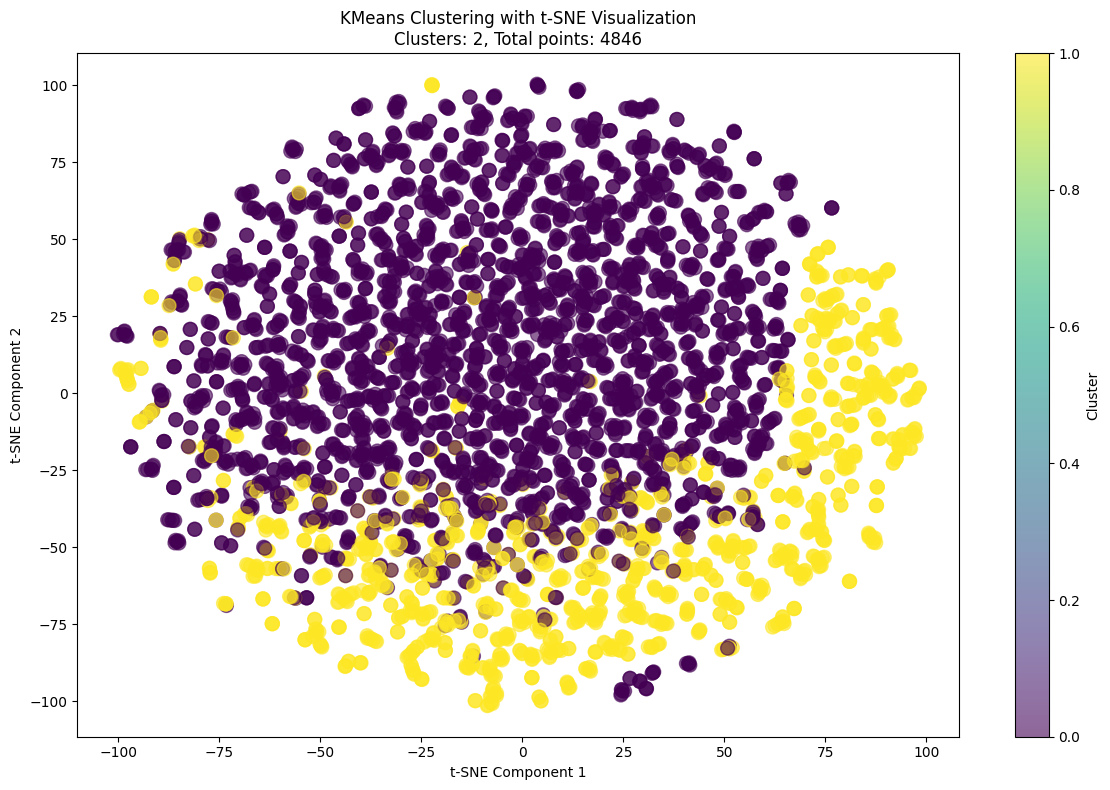

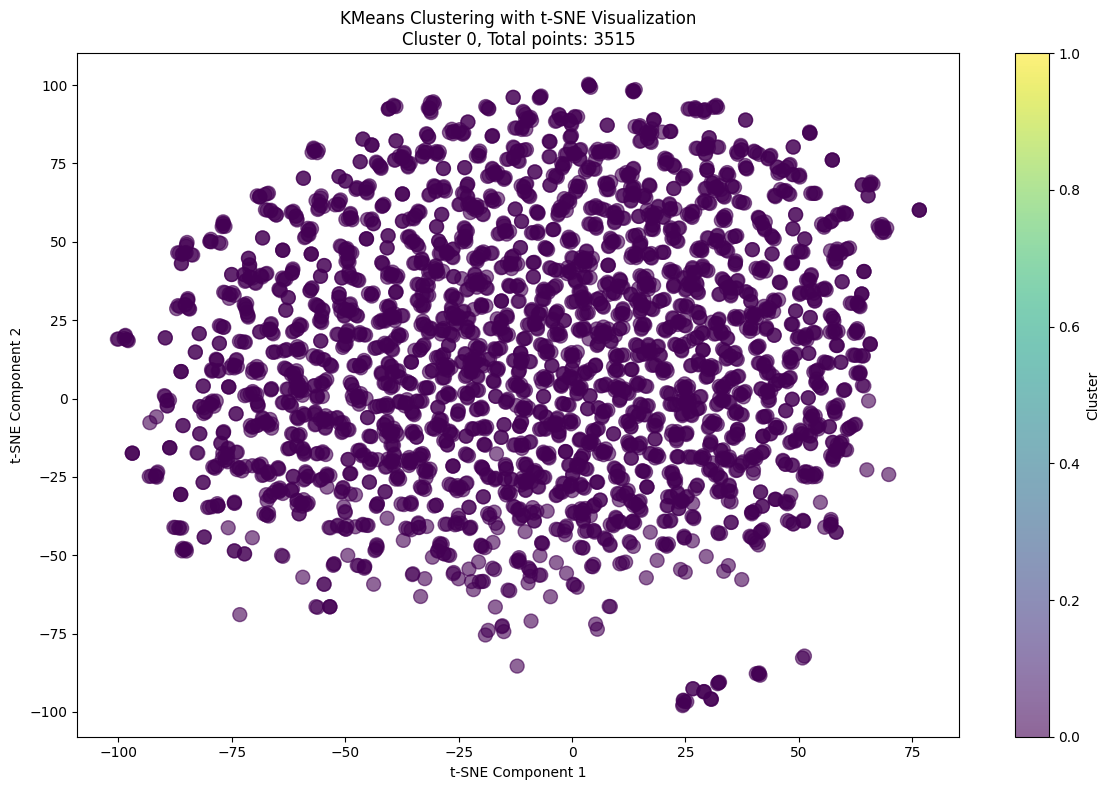

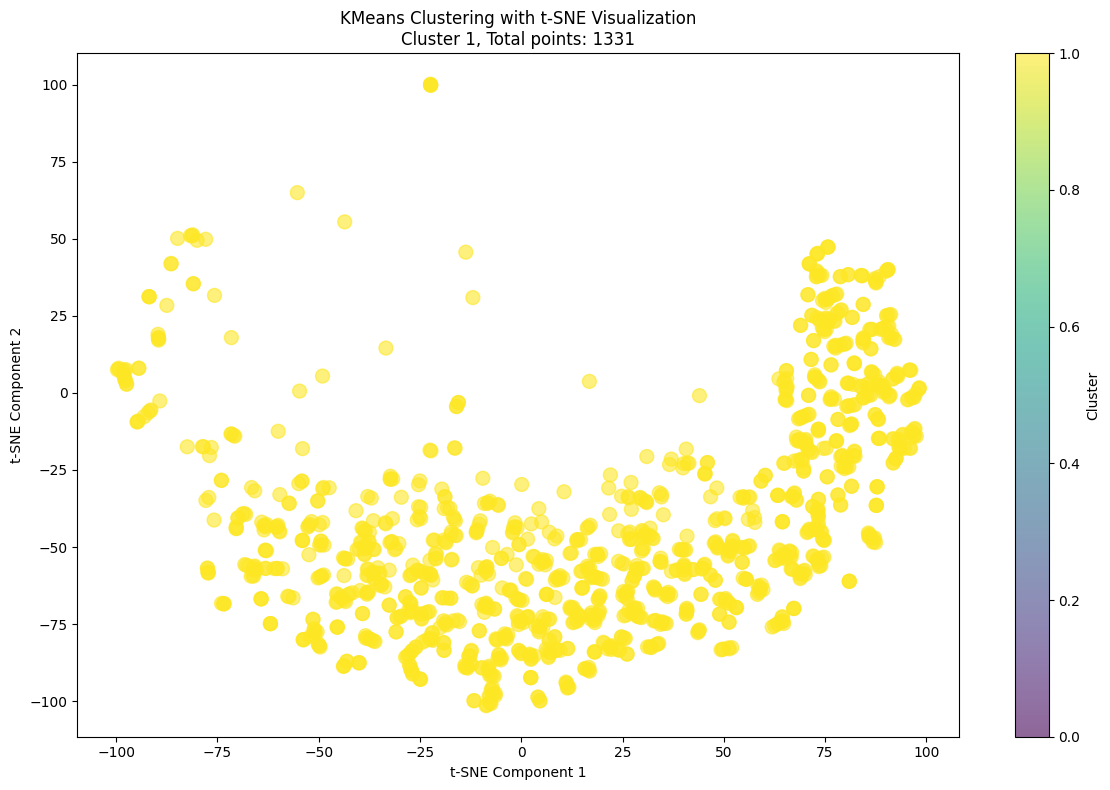


--- Sample Sentences Per Cluster ---

Cluster 0 (3515 sentences):
  Label 0 (Non-Prediction): 3137 sentences (89.2%)
  Label 1 (Prediction): 378 sentences (10.8%)

  Sample Sentences:
  - [1] The first charging stations will be made available already in 2008 and a whole network is to be ready in 2010 .
  - [0] Secure your files online Like filling out a tax return , making a backup is boring .
  - [0] The area will also include some central buildings , and Honkarakenne has started negotiations on their delivery .
  - [0] CapMan said the deal 's effect on its cash flow for 2009 totals EUR3 .4 m , but the transaction would not affect its financial results for 2009 as it was executed at fair value .
  - [0] IT services firm TietoEnator was bucking the general trend , holding flat at 22.70 eur , after slipping back from earlier gains .
  - [0] Currently the quarterly applied surcharges differ significantly from the actual market prices .
  - [0] `` Printed fabrics and related design exper

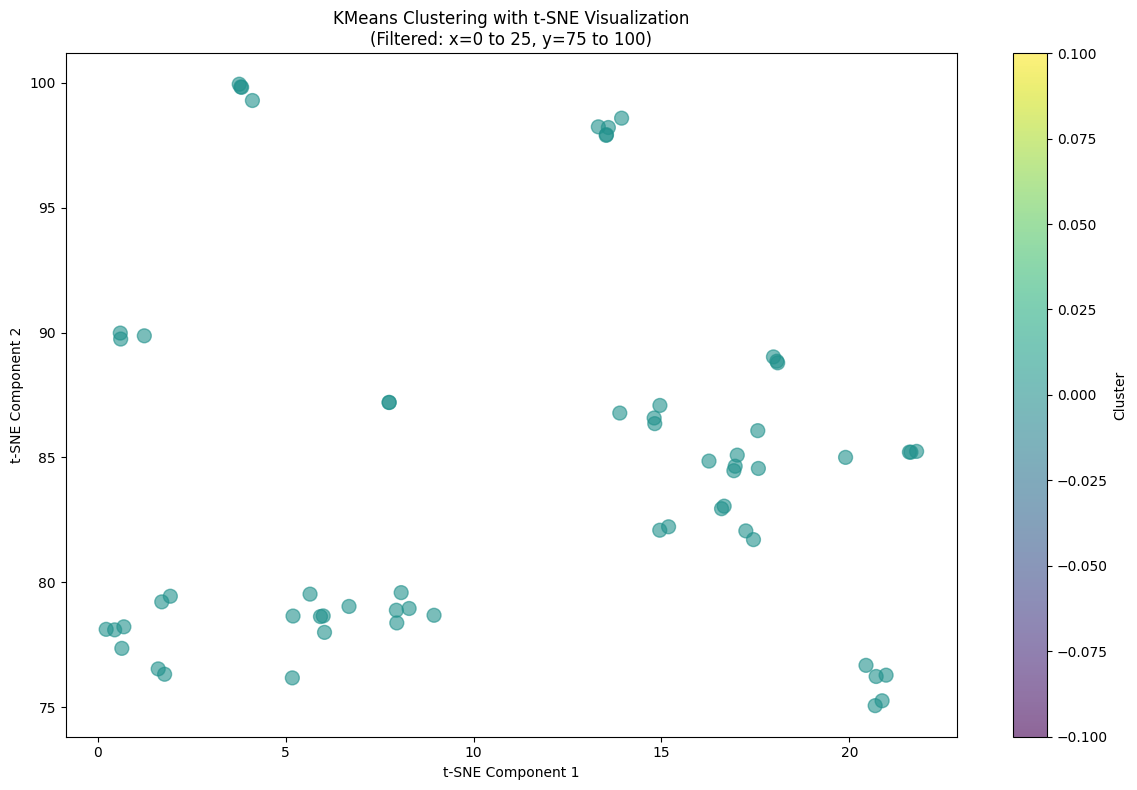


Filtered points: 62 out of 4846


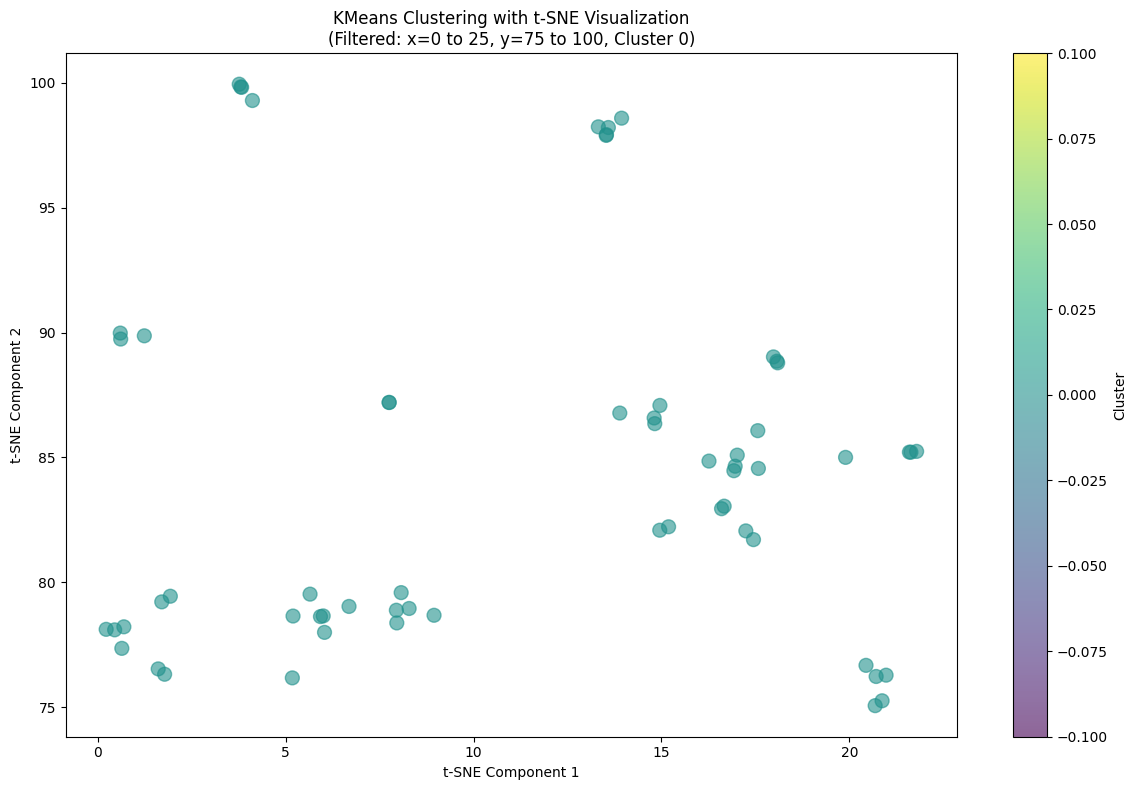


--- Sample Sentences Per Cluster ---

Cluster 0 (62 sentences):
  Label 0 (Non-Prediction): 58 sentences (93.5%)
  Label 1 (Prediction): 4 sentences (6.5%)

  Sample Sentences:
  - [0] The iTunes-based material will be accessible on Windows-based or Macintosh computers and transferable to portable devices , including Apple 's iPods .
  - [0] SSH Establishes New Global Sales and Marketing Group to be led by George Adams ; Adams Establishes Global Sales and Marketing Group to Drive Worldwide Programs Supporting SSH Tectia Enterprise Security Solutions
  - [0] These products include Personal Communications products such as mobile phones and their parts , Home Communications products such as set-top boxes and electronics for flat panel TVs as well as Communications Networks products such as base-stations , tower-top amplifiers , and microwave systems .
  - [0] Elcoteq has a global network of After Market Service sites which have a long experience in serving Consumer Electronics and System

(                                                                                                                                                                                                                         Base Sentence  \
 0   Aldata to Share Space Optimization Vision at Apollo User Group and 2009 Category Management Association Conferences ; Company Will Unveil New Solution that Combines Business Intelligence with Space Planning Data at Conferences   
 1           The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .   
 2                                                                                                                                   By acquiring RCP , we can combine our strong knowhow with the expertise of a solid local company .   
 3                                                          

In [9]:
DataVisualizing.plot_kmeans_tsne(
    df=compare_y_vs_yhats_df,
    text_column='Base Sentence',
    embedding_col_name="Base Sentence Embedding",
    n_clusters=2,
    show_sentences_per_cluster=7,
    sentence_label='Sentence Label',
    filter_x_axis=[0, 25],
    filter_y_axis=[75, 100]
    )

### Region to Filter: Right middle

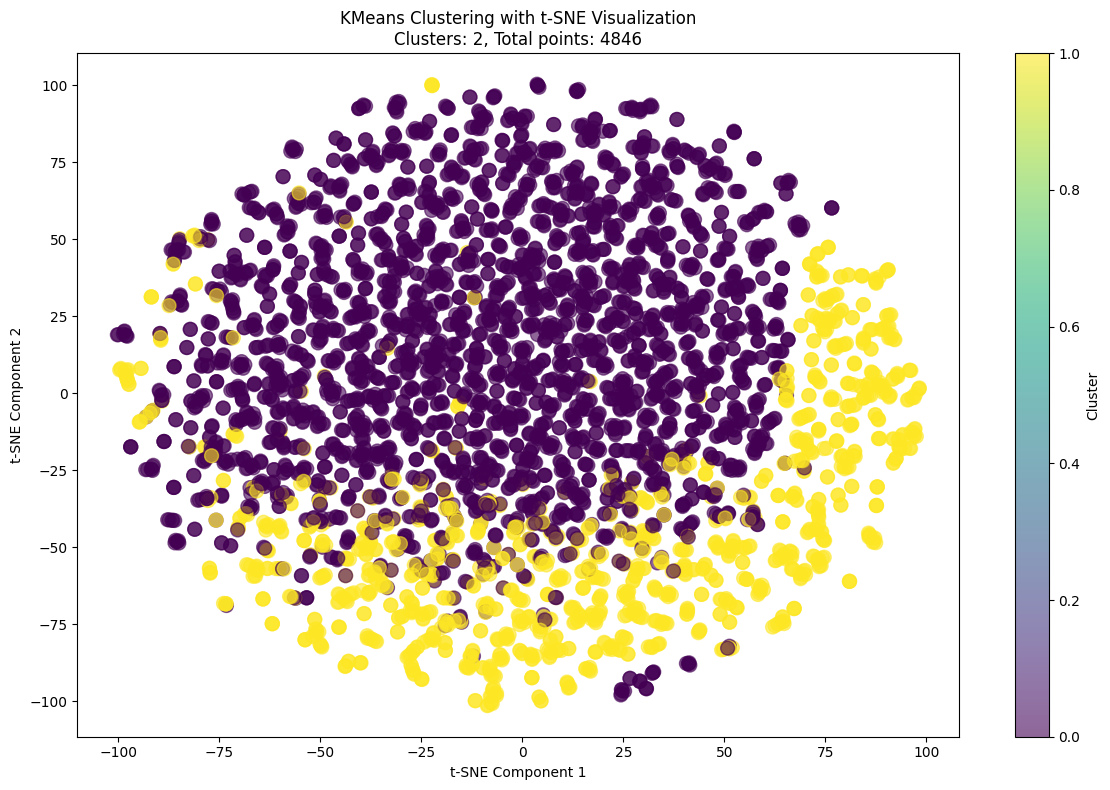

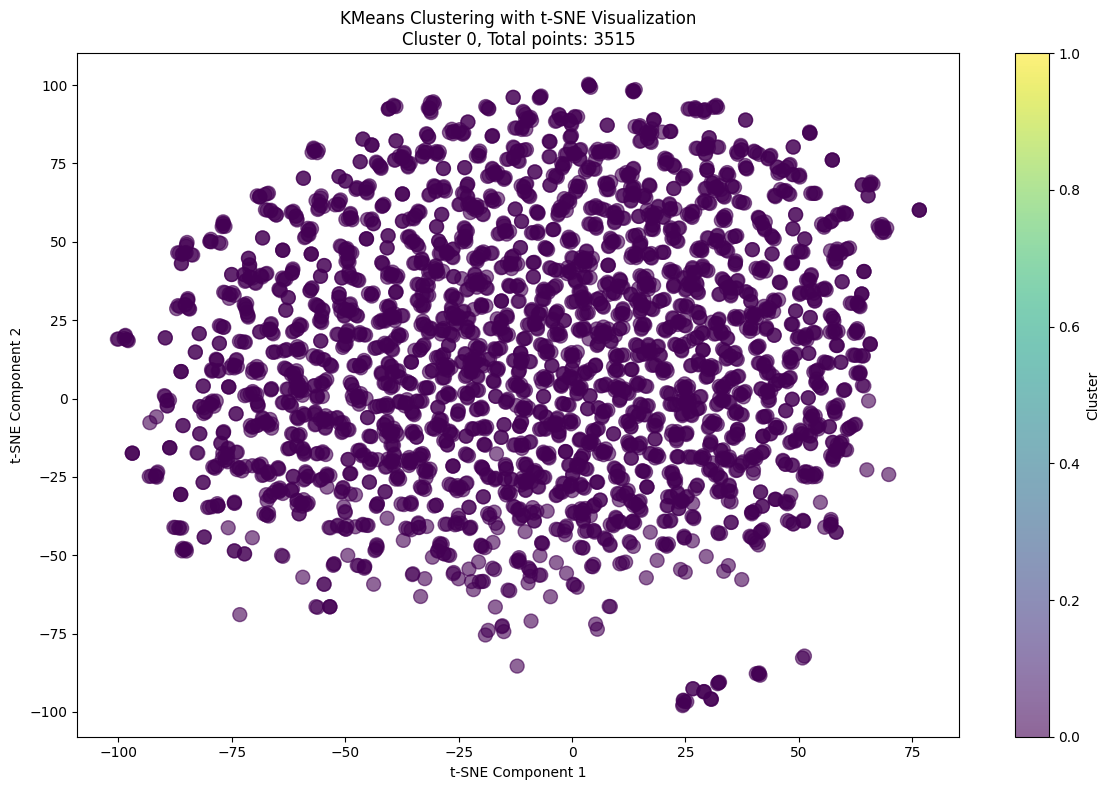

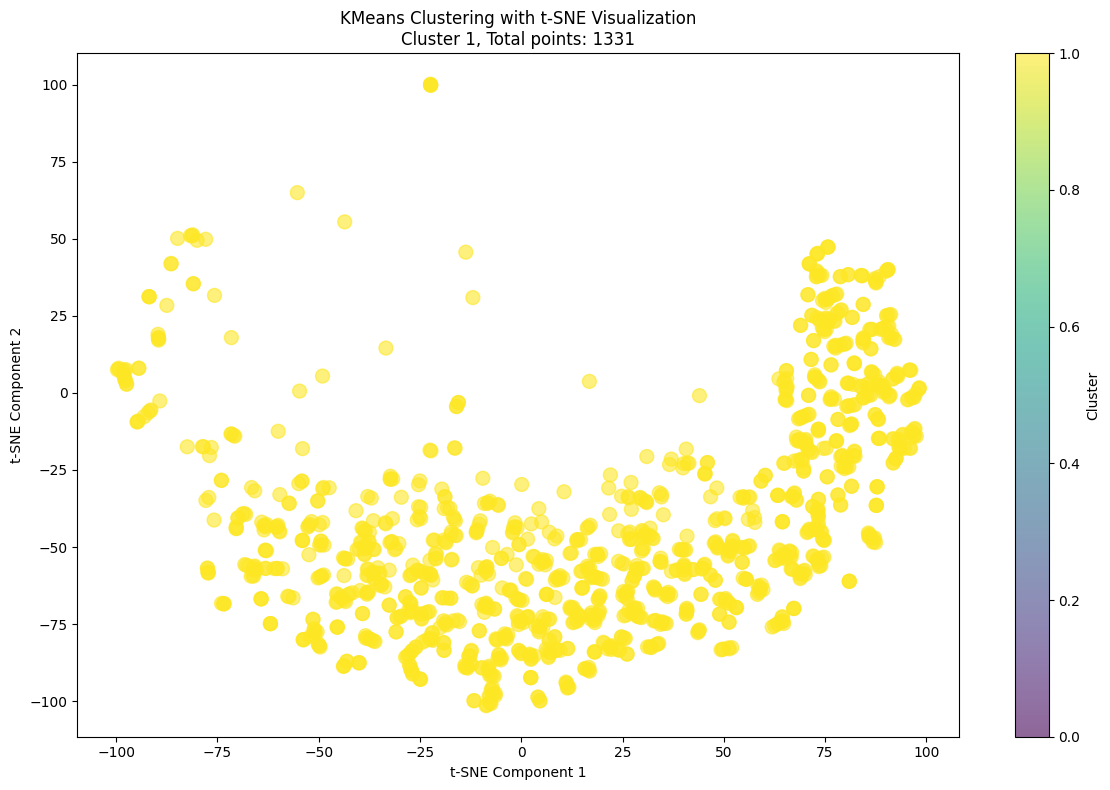


--- Sample Sentences Per Cluster ---

Cluster 0 (3515 sentences):
  Label 0 (Non-Prediction): 3137 sentences (89.2%)
  Label 1 (Prediction): 378 sentences (10.8%)

  Sample Sentences:
  - [0] The percentages of shares and voting rights have been calculated in proportion to the total number of shares registered with the Trade Register and the total number of voting rights related to them .
  - [0] The ECB can mainly target inflation .
  - [1] The shopping center to be opened in St. Petersburg , Russia in November 2010 will turn the cash flow of Finnish department store chain Stockmann 's Russian operations positive for the first time in 2011 .
  - [0] The Diameter Protocol is developed according to the standards IETF RFC 3588 and IETF RFC 3539 .
  - [0] Our solutions are industry-independent supporting multilingual and currency needs , modular and applicable to companies of all sizes , '' CEO Ilkka Sihvo said .
  - [0] The outsourcing agreement , which covers equipment and depots in Tu

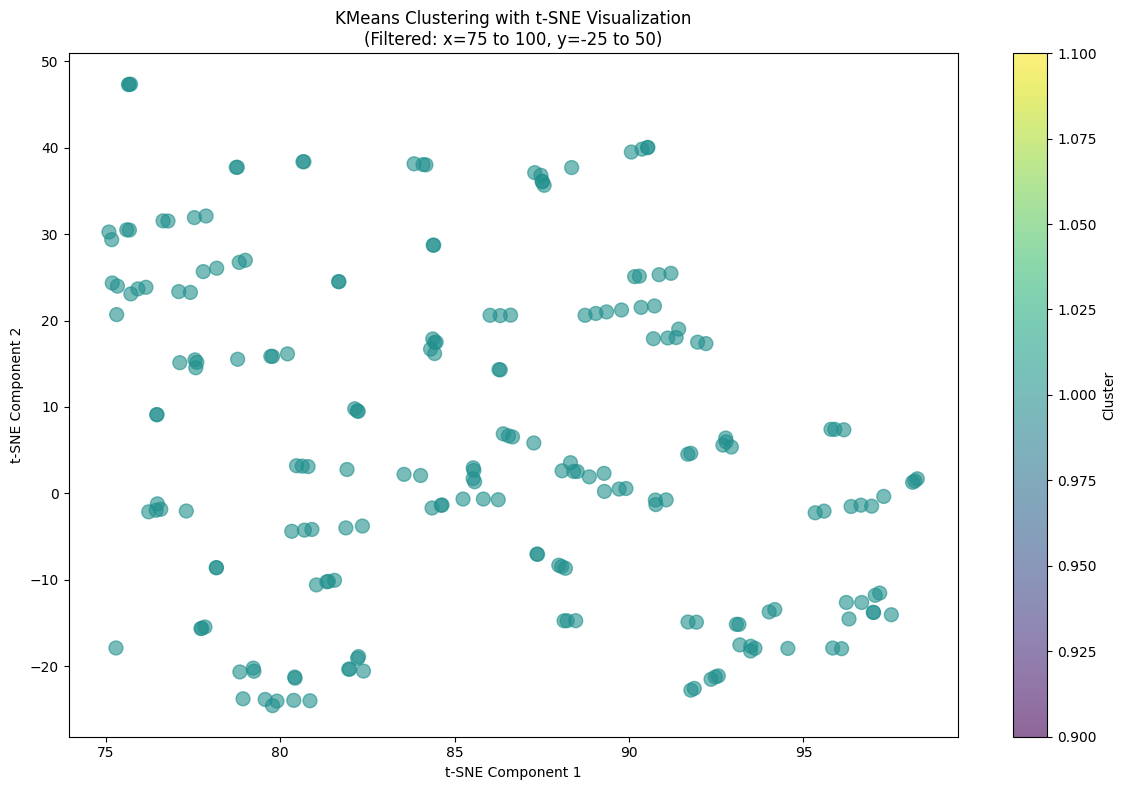


Filtered points: 203 out of 4846


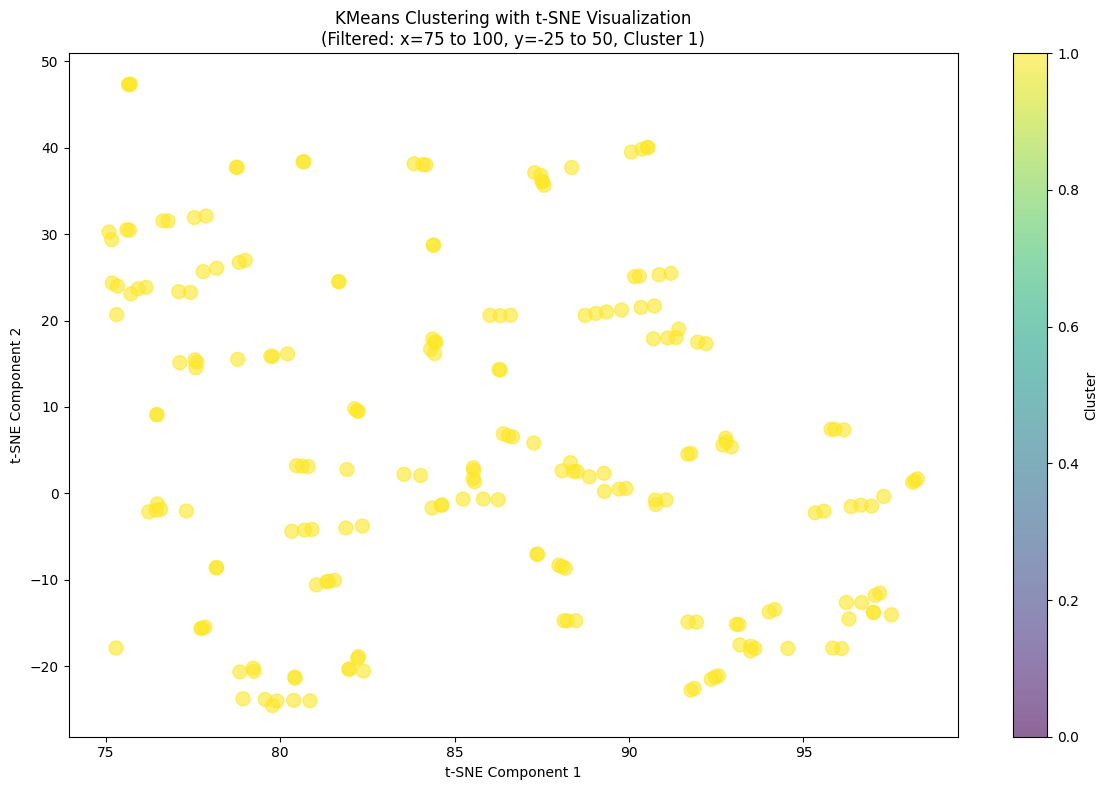


--- Sample Sentences Per Cluster ---

Cluster 1 (203 sentences):
  Label 0 (Non-Prediction): 200 sentences (98.5%)
  Label 1 (Prediction): 3 sentences (1.5%)

  Sample Sentences:
  - [0] Operating profit excluding restructuring costs grew to EUR 44.5 million from EUR 31.7 million while operating profit including restructuring costs showed even larger growth to EUR 38.5 million from EUR 7.4 million .
  - [0] Operating profit decreased to nearly EUR 1.7 mn , however .
  - [0] A total of 16.5 mn passenger ship journeys took place in the northern Baltic Sea in 2007 , slightly down from 16.5 mn in 2006 .
  - [0] Operating result showed a loss of EUR 2.9 mn , while a year before , it showed a profit of EUR 0.6 mn .
  - [0] Operating profit of operations in Finland in the period under review totaled EUR 11.3 mn , remaining at the 2005 level .
  - [0] Profit for the period was EUR 15.6 mn compared to EUR 14.1 mn in 2007 .
  - [0] Finnish pharmaceuticals company Orion reports profit before tax

(                                                                                                                                                                                                                          Base Sentence  \
 0                                                                                                                  EQ Bank forecasts Olvi 's net sales at EUR 67mn in the second quarter of 2009 , and operating profit at EUR 6.4 mn .   
 1                                                                                                                                                              EBIT excluding non-recurring items was estimated to increase from 2009 .   
 2                                                                                                   Operating profit excluding non-recurring items decreased to EUR 6.2 mn from EUR 16.8 mn in 2007 , representing 2.3 % of net sales .   
 3                                                      

In [10]:
DataVisualizing.plot_kmeans_tsne(
    df=compare_y_vs_yhats_df,
    text_column='Base Sentence',
    embedding_col_name="Base Sentence Embedding",
    n_clusters=2,
    show_sentences_per_cluster=7,
    sentence_label='Sentence Label',
    filter_x_axis=[75, 100],
    filter_y_axis=[-25, 50]
    )

### Takeaways



In [11]:
# past predictions 
# future predictions

# statistical test as well

# Kweku paper
# + Run with corrections
# Class paper
# Class presentation